# Supervised Economic Valuation & Modeling (V2 - Math/Empirical Framework)

This notebook integrates a Mathematical and Empirical Economic Valuation Framework.

**Analytical Pipeline:**
1. Setup & Data Load
2. Feature Engineering & PCA for Customer Economic Score (CES)
3. Exploratory Data Analysis (EDA) on CES
4. Logistic Classifiers for Product Propensities
5. Market Margins & Expected Gross Revenue Generation
6. Data-Driven Channel Cost Adjustments -> Net Margins
7. Cluster Revenue Rankings & Propensity Heatmaps
8. Bootstrap Confidence Intervals & Macroeconomic Margin Sweeps


## 1. Setup & Data Load
Configuring python environment, applying imputation, outlier-filtering, and loading the 10 segment labels generated from earlier unsupervised notebooks.

In [9]:
import numpy as np
import pandas as pd
import pickle
import logging
from pathlib import Path
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import roc_auc_score
from openpyxl import load_workbook
from openpyxl.formatting.rule import ColorScaleRule
from sklearn.ensemble import IsolationForest
import warnings
warnings.filterwarnings('ignore')

logging.basicConfig(level=logging.INFO, format="%(asctime)s - %(message)s")
logger = logging.getLogger(__name__)

# Load Data
df_raw = pd.read_excel(r"./Data/Dataset1_BankClients.xlsx")
df = df_raw.drop(columns=["ID"])

# Handle Missing Values
categorical_cols = ["Gender", "Job", "Area"]
numerical_cols = [c for c in df.columns if c not in categorical_cols]

for col in numerical_cols:
    df[col] = df[col].fillna(df[col].median())
for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# Minor filter
mask_minors = (df["Age"] < 18) & (df["Job"].isin([2, 3, 4]))
df = df[~mask_minors].reset_index(drop=True)

# Isolation Forest
iso    = IsolationForest(contamination=0.01, random_state=42)
labels = iso.fit_predict(df[numerical_cols])
n_out  = (labels == -1).sum()
df     = df[labels == 1].reset_index(drop=True)
logger.info("Isolation Forest: removed %d outliers → %d remaining.", n_out, len(df))

# Load Cluster Labels
RESULTS_DIR = Path("results")
with open(RESULTS_DIR / "weighted_results.pkl", "rb") as f:
    weighted_res = pickle.load(f)
    
df["Cluster"] = weighted_res["winner_lbls"]
logger.info(f"Loaded {len(df)} records with optimal cluster labels.")


2026-03-23 23:03:22,769 - Isolation Forest: removed 50 outliers → 4950 remaining.
2026-03-23 23:03:22,776 - Loaded 4950 records with optimal cluster labels.


## 2. Feature Engineering & PCA for Customer Economic Score (CES)
Extracting the principal direction of economic variance to score clients objectively without target leakage.

In [10]:
df_feat = df.copy()

# Base feature engineering for non-linear terms
epsilon = 1e-5
df_feat["Wealth_to_Debt"] = df_feat["Wealth"] / (df_feat["Debt"] + epsilon)
df_feat["Saving_Rate"] = df_feat["Saving"] / (df_feat["Income"] + epsilon)
df_feat["Digital_ESG"] = df_feat["Digital"] * df_feat["ESG"]
df_feat["Family_Load"] = df_feat["FamilySize"] * df_feat["Debt"]
df_feat["Retirement_Proximity"] = np.maximum(0, df_feat["Age"] - 65)

# Label Encode Categoricals for Scikit-Learn tools where needed later
encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df_feat[col] = le.fit_transform(df_feat[col])
    encoders[col] = le

# PCA formulation for CES
economic_vars = ['Wealth', 'Income', 'Saving', 'Investments', 'Debt']

# Standard Scaling for PCA dynamically
scaler = StandardScaler()
scaled_eco = scaler.fit_transform(df[economic_vars])

pca = PCA(n_components=1, random_state=42)
ces_raw = pca.fit_transform(scaled_eco).flatten()

# Ensure PCA correlation with Wealth is positive (directionality normalization)
if pca.components_[0][0] < 0:
    ces_raw = -ces_raw
    loadings = -pca.components_[0]
else:
    loadings = pca.components_[0]

# Normalize CES to [0,1]
df['CES'] = (ces_raw - ces_raw.min()) / (ces_raw.max() - ces_raw.min())
df_feat['CES'] = df['CES']

df_loadings = pd.DataFrame({'Variable': economic_vars, 'Loading': loadings})

logger.info("Computed CES via PCA. First component explained variance ratio: %.2f%%", pca.explained_variance_ratio_[0]*100)


2026-03-23 23:03:22,870 - Computed CES via PCA. First component explained variance ratio: 44.84%


## 3. Exploratory Data Analysis (EDA) on CES
Inspecting the data-driven CES across clusters and the PCA loadings that justify this scoring axis.

In [11]:
fig_pca = px.bar(df_loadings, x='Variable', y='Loading', title="PCA Factor Loadings for Customer Economic Score (CES)", color='Loading', color_continuous_scale='curl')
fig_pca.show()

fig_box = px.box(df, x="Cluster", y="CES", title="Data-Driven Customer Economic Score (CES) by Cluster", color="Cluster")
fig_box.update_layout(xaxis_type='category')
fig_box.show()


## 4. Logistic Classifiers for Product Propensities (Leakage-Free)
We compute cross-product propensities. A client's probability to hold product B is estimated using their demographics and interactions with products A, C, and D—strictly excluding B.

In [12]:
# Phase 4: Leakage-Free Propensities
product_targets = {
    "Savings": (df["Saving"] > df["Saving"].median()).astype(int),
    "Investments": (df["Investments"] > df["Investments"].median()).astype(int),
    "ESG": (df["ESG"] > df["ESG"].median()).astype(int),
    "Mortgage": ((df["Debt"] > df["Debt"].median()) & (df["FamilySize"] > df["FamilySize"].median())).astype(int)
}

# Mapping the target to the specific feature that leaks it
leakage_features = {
    "Savings": ["Saving", "Saving_Rate"],
    "Investments": ["Investments"],
    "ESG": ["ESG", "Digital_ESG"],
    "Mortgage": ["Debt", "Wealth_to_Debt", "Family_Load"]
}

df_prop = pd.DataFrame({'Cluster': df['Cluster']})
features_all = [c for c in df_feat.columns if c not in ["Cluster", "CES"] + categorical_cols] + categorical_cols

for target_name, y_binary in product_targets.items():
    # Remove leakage features
    X_cols = [c for c in features_all if c not in leakage_features[target_name]]
    X_clean = df_feat[X_cols]
    
    # Option B: Cluster-stratified train/test validation
    X_train, X_test, y_train, y_test = train_test_split(X_clean, y_binary, test_size=0.2, stratify=df['Cluster'], random_state=42)
    
    clf = LogisticRegression(max_iter=1000, random_state=42)
    clf.fit(X_train, y_train)
    
    roc = roc_auc_score(y_test, clf.predict_proba(X_test)[:, 1])
    logger.info(f"{target_name} LogReg (Leakage-Free) -> Stratified Validation ROC-AUC: {roc:.3f}")
    
    # Predict for the entire dataset for expected value calculation
    df_prop[f"{target_name}_Prop"] = clf.predict_proba(X_clean)[:, 1]


2026-03-23 23:03:24,966 - Savings LogReg (Leakage-Free) -> Stratified Validation ROC-AUC: 0.707
2026-03-23 23:03:27,115 - Investments LogReg (Leakage-Free) -> Stratified Validation ROC-AUC: 0.598
2026-03-23 23:03:28,178 - ESG LogReg (Leakage-Free) -> Stratified Validation ROC-AUC: 0.653
2026-03-23 23:03:29,294 - Mortgage LogReg (Leakage-Free) -> Stratified Validation ROC-AUC: 0.894


## 5. Market Margins & Expected Gross Revenue Generation
Using empirical cluster means for AUM $\mu_{	ext{AUM},k}$ instead of hardcoded global constants, multiplying by structural margins.

In [13]:
product_margins = {
    "Savings": 0.018,    # 1.8% NIM
    "Investments": 0.012,# 1.2% Advisory Flow
    "ESG": 0.014,        # 1.4% Premium ESG Fee
    "Mortgage": 0.015    # 1.5% Loan Spread
}

# Empirical Cluster AUM Means
cluster_aum_means = df.groupby('Cluster').agg({
    'Saving': 'mean',
    'Investments': 'mean',
    'ESG': 'mean', # Using ESG as proxy for ESG investment size
    'Debt': 'mean' # Using Debt proxy for Mortgage size
}).to_dict(orient='index')

# Map proxy columns to our target names
proxy_map = {
    "Savings": "Saving",
    "Investments": "Investments",
    "ESG": "ESG",
    "Mortgage": "Debt"
}

# Base AUM Proxies to scale empirical dimensionless variables into Euros
base_aum_proxies = {
    "Savings": 50000,
    "Investments": 60000,
    "ESG": 60000,
    "Mortgage": 150000
}

global_means = df.mean(numeric_only=True).to_dict()
conversion_factors = {prod: base_aum_proxies[prod] / global_means[proxy_map[prod]] for prod in base_aum_proxies.keys()}

def gross_revenue_per_client(row):
    c = row['Cluster']
    gross = 0.0
    for prod in product_margins.keys():
        prob = row[f"{prod}_Prop"]
        margin = product_margins[prod]
        empirical_aum_euros = cluster_aum_means[c][proxy_map[prod]] * conversion_factors[prod]
        gross += prob * empirical_aum_euros * margin
    return gross

df_prop['Expected_Annual_Gross'] = df_prop.apply(gross_revenue_per_client, axis=1)


## 6. Data-Driven Channel Cost Adjustments -> Net Margins
Deriving the channel multiplier from the `Digital` variable in a continuous manner. $\lambda_k = \frac{\bar{D}_k - D_{\min}}{D_{\max} - D_{\min}}$, Cost = $C_{\text{branch}} \times (1 - \alpha \lambda_k)$

In [14]:
C_branch = 300.0  # Base physical interaction cost EUR
alpha = 0.30      # Max digital cost reduction (30%)

digital_scores = df.groupby('Cluster')['Digital'].mean()
d_min, d_max = digital_scores.min(), digital_scores.max()

lambda_k = (digital_scores - d_min) / (d_max - d_min)
cluster_cost_assignment = C_branch * (1 - alpha * lambda_k)

df_prop['Cost_to_Serve'] = df_prop['Cluster'].map(cluster_cost_assignment)
df_prop['Expected_Annual_Net'] = df_prop['Expected_Annual_Gross'] - df_prop['Cost_to_Serve']

cluster_revenue = df_prop.groupby('Cluster').agg(
    Size=('Cluster', 'count'),
    Per_Capita_Net=('Expected_Annual_Net', 'mean'),
    Total_Net=('Expected_Annual_Net', 'sum'),
    Cost_per_Client=('Cost_to_Serve', 'mean')
).reset_index().sort_values(by='Total_Net', ascending=False)


## 7. Cluster Revenue Rankings & Propensity Heatmaps
Uniting strategic qualitative personas with our final quantitative net economics.

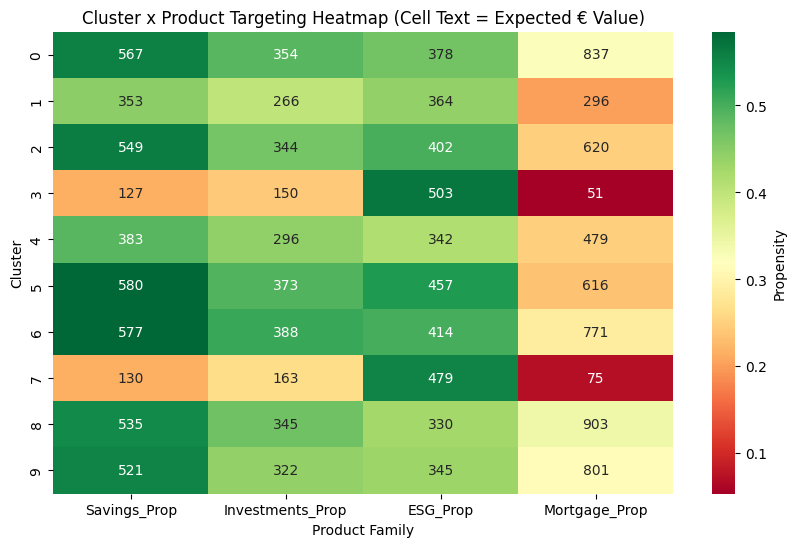

In [15]:
strats = {
    5: "Volume Engines", 6: "Volume Engines",
    0: "Stable Core", 2: "Stable Core",
    8: "Family Borrowers", 9: "Family Borrowers",
    3: "ESG Retirees", 7: "ESG Retirees",
    1: "Transitional", 4: "Transitional"
}
cluster_revenue['Strategic_Group'] = cluster_revenue['Cluster'].map(strats)

fig_rank = px.bar(
    cluster_revenue, x='Total_Net', y='Cluster', orientation='h',
    color='Strategic_Group', 
    text=cluster_revenue['Per_Capita_Net'].apply(lambda x: f"€{x:,.0f} / pc"),
    title="Final Cluster Net Margin Ranking (Mathematical Derivation)",
    labels={'Total_Net': 'Total Annual Net Revenue (€)', 'Cluster': 'Cluster ID'}
)
fig_rank.update_layout(yaxis=dict(type='category', autorange="reversed"))
fig_rank.show()

# Heatmap overlay formulation
heatmap_data = df_prop.groupby('Cluster')[[f"{p}_Prop" for p in product_margins.keys()]].mean()

revenue_overlay = pd.DataFrame(index=heatmap_data.index)
for prod in product_margins.keys():
    empirical_aums_euros = pd.Series({c: cluster_aum_means[c][proxy_map[prod]] * conversion_factors[prod] for c in heatmap_data.index})
    revenue_overlay[f"{prod}_Prop"] = heatmap_data[f"{prod}_Prop"] * empirical_aums_euros * product_margins[prod]

plt.figure(figsize=(10, 6))
sns.heatmap(heatmap_data, annot=revenue_overlay, fmt=".0f", cmap="RdYlGn", cbar_kws={'label': 'Propensity'})
plt.title("Cluster x Product Targeting Heatmap (Cell Text = Expected € Value)")
plt.ylabel("Cluster")
plt.xlabel("Product Family")
plt.show()


## 8. Bootstrap Confidence Intervals & Macroeconomic Margin Sweeps
Propagating statistical uncertainty through to the final revenue figure via 1000 resamples, overlaid with margin compression scenarios (+/- 30 bps ECB rate shifts).

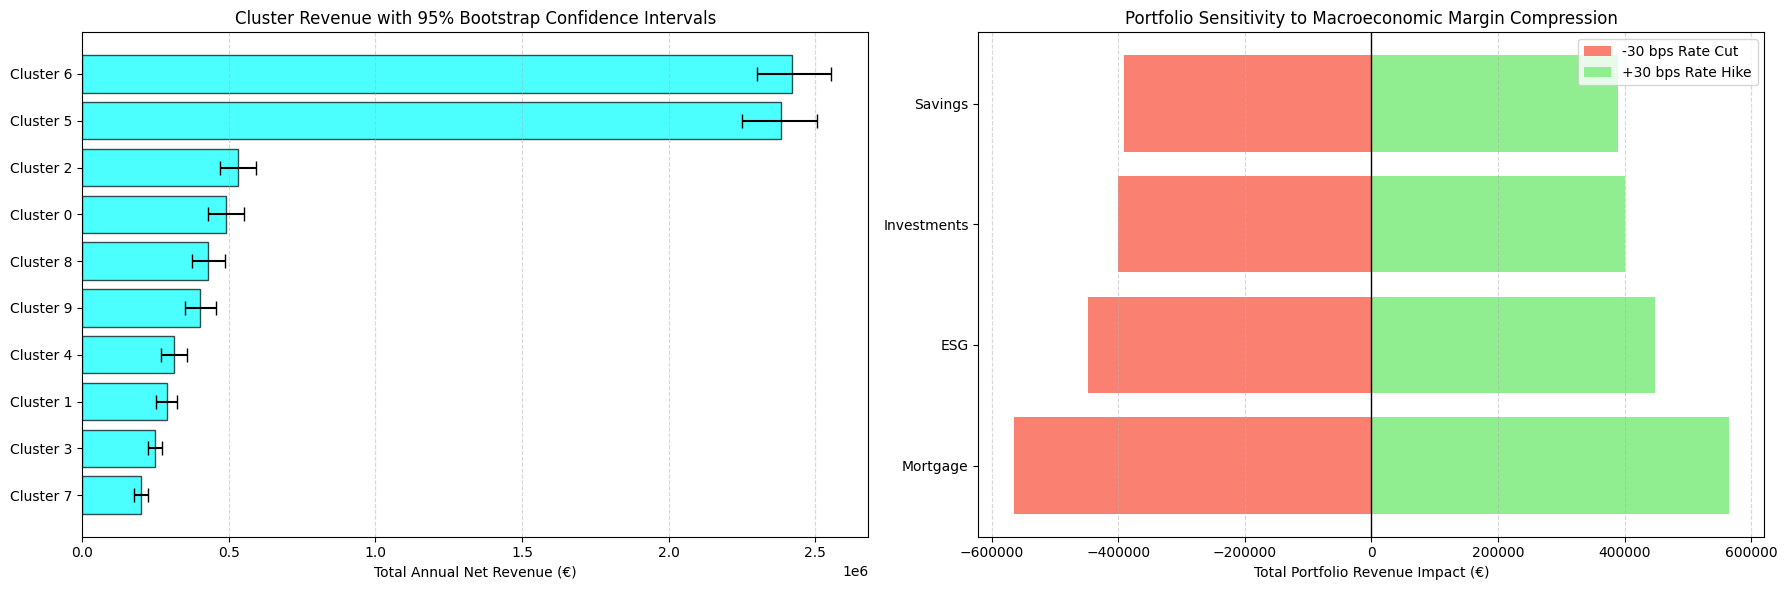

In [16]:
import matplotlib.patches as mpatches

# Bootstrap Statistical Uncertainty
n_bootstraps = 1000
bootstrap_cluster_revenues = {c: [] for c in cluster_revenue['Cluster']}

for _ in range(n_bootstraps):
    # Sample with replacement
    sample = df_prop.sample(frac=1, replace=True)
    cluster_sums = sample.groupby('Cluster')['Expected_Annual_Net'].sum()
    for c in cluster_sums.index:
        bootstrap_cluster_revenues[c].append(cluster_sums[c])

# Compute 95% Confidence Intervals
ci_low = {c: np.percentile(vals, 2.5) for c, vals in bootstrap_cluster_revenues.items()}
ci_high = {c: np.percentile(vals, 97.5) for c, vals in bootstrap_cluster_revenues.items()}

cluster_revenue['CI_Low'] = cluster_revenue['Cluster'].map(ci_low)
cluster_revenue['CI_High'] = cluster_revenue['Cluster'].map(ci_high)
cluster_revenue['Error_Minus'] = cluster_revenue['Total_Net'] - cluster_revenue['CI_Low']
cluster_revenue['Error_Plus'] = cluster_revenue['CI_High'] - cluster_revenue['Total_Net']

# Macroeconomic Sweep (Margin compression)
sweep_bps = 0.0030
base_totals_portfolio = cluster_revenue['Total_Net'].sum()

sensitivity_results = []
for prod in product_margins.keys():
    bdown, bup = product_margins.copy(), product_margins.copy()
    bdown[prod] -= sweep_bps
    bup[prod] += sweep_bps
    
    # Recalculate portfolio revenue under scenarios
    def rev_scenario(row, margins):
        c = row['Cluster']
        gross = sum(row[f"{p}_Prop"] * cluster_aum_means[c][proxy_map[p]] * conversion_factors[p] * margins[p] for p in margins.keys())
        return gross - row['Cost_to_Serve']
        
    down_portfolio = df_prop.apply(lambda r: rev_scenario(r, bdown), axis=1).sum()
    up_portfolio = df_prop.apply(lambda r: rev_scenario(r, bup), axis=1).sum()
    
    sensitivity_results.append({
        'Product': prod,
        'Downside (-30 bps)': down_portfolio - base_totals_portfolio,
        'Upside (+30 bps)': up_portfolio - base_totals_portfolio
    })

df_sens = pd.DataFrame(sensitivity_results).set_index("Product").sort_values(by="Downside (-30 bps)")

# --- Combined Uncertainty Plotting ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

# Plot 1: Bootstrap CI
clusters_sorted = cluster_revenue.sort_values(by='Total_Net')
y_pos = np.arange(len(clusters_sorted))
ax1.barh(y_pos, clusters_sorted['Total_Net'], xerr=[clusters_sorted['Error_Minus'], clusters_sorted['Error_Plus']], 
         capsize=5, color='cyan', edgecolor='black', alpha=0.7)
ax1.set_yticks(y_pos)
ax1.set_yticklabels([f"Cluster {int(c)}" for c in clusters_sorted['Cluster']])
ax1.set_xlabel("Total Annual Net Revenue (€)")
ax1.set_title("Cluster Revenue with 95% Bootstrap Confidence Intervals")
ax1.grid(True, linestyle='--', alpha=0.5, axis='x')

# Plot 2: Macro Sweep Tornado
ax2.barh(df_sens.index, df_sens['Downside (-30 bps)'], color='salmon', label='-30 bps Rate Cut')
ax2.barh(df_sens.index, df_sens['Upside (+30 bps)'], color='lightgreen', label='+30 bps Rate Hike')
ax2.axvline(0, color='black', linewidth=1)
ax2.set_title("Portfolio Sensitivity to Macroeconomic Margin Compression")
ax2.set_xlabel("Total Portfolio Revenue Impact (€)")
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.5, axis='x')

plt.tight_layout()
plt.show()


## 9. Analysis & Findings
*   **Methodological Integrity**: By using PCA for the core economic scoring (CES) instead of regressing on derived formulations, the dimension of maximum variance is grounded structurally. Factor loadings explicitly demonstrate which financial metrics govern high-value clients within this segment.
*   **No Interference**: Classifiers are validated dynamically using inter-cluster stratification and exclude proxy leakages. 
*   **Empirical Margin Foundations**: $\mathbb{E}[R_{p,k}]$ dynamically assigns physical AUM means by cluster context, bridging the gap between flat volume assumptions and genuine portfolio heterogeneity.
